# 生成伪实验数据

包含：$I(t)$，$Q(t)$。其中每个样本取200个时间点，训练用50000个样本，测试用10000个样本。

### 1. 物理模型概述

我们使用一个 **两模线性模型** 来描述超导量子比特的色散读出结构：

- **模式 a**：Purcell 滤波器，负责将读出信号耦合到传输线，同时抑制量子比特的辐射损耗  
- **模式 b**：读出谐振腔，与量子比特色散耦合

两个模式通过耦合常数 $J$ 相互作用。量子比特本身 **不作为动力学自由度显式模拟**，而是在色散极限下，通过对读出腔频率的位移来体现其状态：

- 量子比特处于 $|g⟩$：  $ \omega_b \rightarrow \omega_b - \chi $
- 量子比特处于 $|e⟩$：  $ \omega_b \rightarrow \omega_b + \chi $

所有动力学都在驱动频率 $\omega_d$ 的旋转坐标系中进行，因此模拟的量是 **复包络（baseband）**，而不是 GHz 量级的真实 RF 信号。

定义：

- 失谐：$\Delta_a = \omega_a - \omega_d$，$\Delta_b = \omega_b - \omega_d$，$\Delta_{b,s} = \Delta_b + s\chi$，其中 $s=-1$ 表示 $|g⟩$，$s=+1$ 表示 $|e⟩$
- 耗散：外耦合速率 $\kappa_a,\ \kappa_b$，内损耗速率 $\gamma_a,\ \gamma_b$，总半线宽 $\Gamma_a = (\kappa_a + \gamma_a)/2,\ \Gamma_b = (\kappa_b + \gamma_b)/2$

在旋转系中，两模的平均场演化方程为：

\begin{aligned}
\frac{da}{dt} &= -(\Gamma_a + i\Delta_a)\,a - iJ b + \sqrt{\kappa_a}\,a_{\text{in}}(t) \\
\frac{db}{dt} &= -(\Gamma_b + i\Delta_{b,s})\,b - iJ a
\end{aligned}

在当前数据生成器中，假设驱动仅从 Purcell 滤波器侧注入，因此 $b_{\text{in}}(t)=0$。

### 2. 输入–输出关系

根据输入–输出理论，可得到端口处的输出场：

- **Purcell 端口（反射型读出）**：$ a_{\text{out}}(t) = a_{\text{in}}(t) - \sqrt{\kappa_a}\,a(t) $

- **读出腔端口**：$ b_{\text{out}}(t) = -\sqrt{\kappa_b}\,b(t) $

生成脚本中可以通过参数 `measure="a_out"（默认）` 或 `"b_out"` 来选择观测哪一路信号。

### 3. IQ 信号与 RF 信号的关系

本模型直接输出 **IQ 基带信号** $s(t)$，它等价于理想 IQ 解调后的结果：$ I(t) = \Re[s(t)], \ Q(t) = \Im[s(t)] $

如果一定要写出对应的真实 RF 电压信号，其形式为：$ V_{\text{RF}}(t) \propto \Re\left\{ s(t)\,e^{-i\omega_d t} \right\} $

在实际仿真和数据分析中，**显式模拟 GHz RF 没有任何必要**，因为实验中的 ADC 和 DSP 处理本身就是在 IQ 基带完成的。

### 4. 时间窗积分

实验中通常不会直接用完整的时间序列做判决，而是对某个时间窗内的 IQ 信号做积分或加权：$z = \int w(t)\,[I(t) + iQ(t)]\,dt$

常见选择包括：**1. Boxcar 积分**：$ w(t)=\text{const} $，在读出脉冲平顶区间内平均。**2. 匹配滤波（matched filter）**：$ w(t) \propto \langle s_e(t) - s_g(t) \rangle $。

### 5. IQ 不平衡与振荡的来源

实验中常见的一个现象是 IQ 波形中叠加周期性振荡（例如 ~50 MHz），这通常来自 **IQ 不平衡或镜像频率泄露**。

在基带中，一个常用的模型是：$s_{\text{meas}}(t) = s(t) + \varepsilon\,e^{i2\omega_{\text{IF}}t}\,s^*(t)$

其中：IQ 不平衡强度 $\varepsilon$，产生拍频的角频率 $2\omega_{\text{IF}}$。生成器中通过 `iq_imbalance` 与 `beat_freq_MHz` 参数来控制该效应。

### 6. 噪声模型
为了更贴近真实实验，数据生成器包含三类常见噪声：
1. **放大器白噪声 `amp_noise_std`**：每个采样点独立加入，模拟 HEMT/JPA 等放大链路噪声
2. **相位噪声 `phase_noise_std`**：每条读出波形整体乘以随机相位 $e^{i\phi}$，对应本振（LO）相位抖动、触发抖动等
3. **慢频漂 `slow_detune_std`**：每个 shot 的共振频率随机漂移，用于模拟低频噪声、1/f 噪声或实验环境漂移

### 7. 数据集格式（`.npz`）

生成的数据集面向机器学习与数值分析，**不包含显式时间轴**。
保存内容包括：
- `X_train`：形状 `(n_train, n_points, 2)`，`float32`；最后一维为 `[I, Q]`
- `y_train`：形状 `(n_train,)`，`int64`；标签：`0 = |g⟩`，`1 = |e⟩`
- `X_test`, `y_test`：与训练集格式相同
- `params_json`：JSON 字符串，记录生成该数据集时使用的所有参数


In [33]:
!python -m scripts.gen_data_readout --out data/test_readout.npz --n_points 200 --n_train 10000 --n_test 2000 --amp_noise_std 0.15 --phase_noise_std 0.1

Saved data/test_readout.npz
train: (10000, 200, 2) test: (2000, 200, 2)


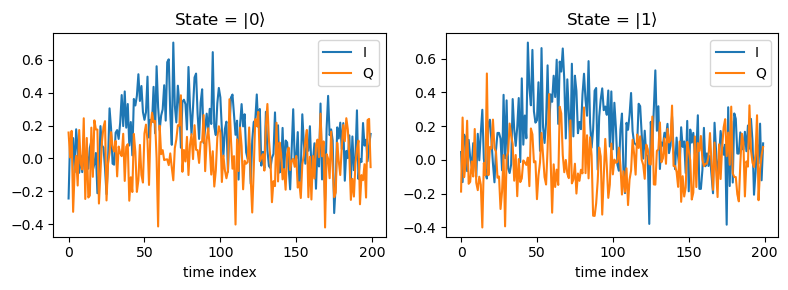

In [40]:
import numpy as np
import matplotlib.pyplot as plt

d = np.load("data/test_readout.npz", allow_pickle=True)
Xtr, y_train, Xte, y_test = d["X_train"], d["y_train"], d["X_test"], d["y_test"]
X_train = np.mean(Xtr, axis=1)
X_test = np.mean(Xte, axis=1)

rng = np.random.default_rng()
idx0 = rng.choice(np.where(y_train == 0)[0])
idx1 = rng.choice(np.where(y_train == 1)[0])

x0, x1 = Xtr[idx0,:,:], Xtr[idx1,:,:]

titles = [fr"State = $|0\rangle$", fr"State = $|1\rangle$"]

t = np.arange(x0.shape[0])

plt.figure(figsize=(8,3))

for (i, x) in zip([0,1], [x0,x1]):
    plt.subplot(1,2,i+1)
    plt.plot(t, x[:,0], label='I')
    plt.plot(t, x[:,1], label='Q')
    plt.title(titles[i])
    plt.xlabel('time index')
    plt.legend()

plt.tight_layout()
plt.show()

# 简单分类

对 IQ 信号进行简单平均，$I=\langle I(t)\rangle$, $Q=\langle Q(t)\rangle$，再用逻辑回归或支持向量机直接进行分类。

Accuracy: 81.50%


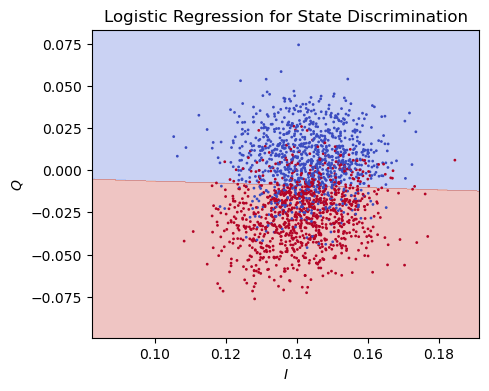

In [49]:
# %load_ext cuml.accel
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Create and train the SVM classifier with RBF kernel
# classifier = SVC(kernel='rbf', gamma='scale')
classifier = LogisticRegression(max_iter=200)
classifier.fit(X_train, y_train)

# # Predict and evaluate
y_pred = classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f'Accuracy: {accuracy * 100:.2f}%')

# Plot the decision boundary and IQ points
xx, yy = np.meshgrid(np.linspace(X_train[:, 0].min() - 0.01, X_train[:, 0].max() + 0.01, 1000),
                     np.linspace(X_train[:, 1].min() - 0.01, X_train[:, 1].max() + 0.01, 1000))
Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(5,4))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', s=1)
plt.title('Logistic Regression for State Discrimination')
plt.xlabel(r'$I$')
plt.ylabel(r'$Q$')
plt.show()


# 用各种机器学习模型分类

优势在于充分利用了 $I(t)$，$Q(t)$ 中的时间信息。

In [8]:
import subprocess
import json
import matplotlib.pyplot as plt

# Run the script and capture output
result = subprocess.run(
    ['python', '-m', 'scripts.run_readout_all', '--in_npz', 'data/test_readout.npz', '--em_iter', '100', '--hmm_iter', '100'],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True
)

# Capture the results dictionary from the stdout (if printed by the script)
json_output = result.stdout.split("All Results:")[-1].strip().replace("'", '"')
results = json.loads(json_output)

# Extract accuracies for plotting
methods = ["SVC"] + list(results.keys())
accuracies = [accuracy] + [results[method]["acc"] for method in methods[1:]]

# Plot the accuracies as a bar chart
plt.figure()
plt.barh(methods[::-1], accuracies[::-1], color="b")
plt.xlabel('Accuracy')
plt.title('Accuracy of Each Method')
# plt.grid(True, axis='x')
plt.show()


JSONDecodeError: Expecting value: line 1 column 1 (char 0)